# Cross-Section Interpolation Settings


In [1]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import ras_commander
from ras_commander import RasCmdr, RasExamples, init_ras_project, ras
from ras_commander.geom.GeomCrossSection import GeomCrossSection

logging.getLogger("ras_commander").setLevel(logging.WARNING)

print(f"ras-commander {ras_commander.__version__}")
print(ras_commander.__file__)

ras-commander 0.96.1
C:\GH\symphony-workspaces\ras-commander\CLB-306\ras_commander\__init__.py


## Local Development

For local-source validation, execute this notebook from the repository with `PYTHONPATH` set to the active checkout and the `symphony-dev` environment selected. Generated HEC-RAS projects and compute outputs are written outside the repository under `H:/Symphony/ras-commander/CLB-306` when that drive is available.

# Cross-Section Interpolation Settings

This notebook validates the CLB-306 cross-section APIs on a real HEC-RAS example project:

- read neighboring 1D cross sections from a plain-text geometry file
- create reviewable interpolated station/elevation data under the HEC-RAS point limit
- enforce explicit bank stations as exact station/elevation points
- round-trip per-cross-section expansion/contraction coefficients
- run HEC-RAS through `RasCmdr.compute_plan()` to validate the edited geometry

In [2]:
preferred_root = Path("H:/Symphony/ras-commander/CLB-306/xs_interpolation_settings")
if Path("H:/").exists():
    work_dir = preferred_root
else:
    cwd = Path.cwd()
    repo_root = cwd if (cwd / "ras_commander").exists() else cwd.parent
    work_dir = repo_root / "working" / "CLB-306-xs-interpolation-settings"

work_dir.mkdir(parents=True, exist_ok=True)

project_name = "Muncie"
project_suffix = "clb306_xs_settings"
ras_version = "6.6"
plan_number = "01"

project_path = RasExamples.extract_project(project_name, output_path=work_dir, suffix=project_suffix)
init_ras_project(project_path, ras_version)

plan_row = ras.plan_df.loc[ras.plan_df["plan_number"].eq(plan_number)].iloc[0]
geom_file = Path(plan_row["Geom Path"])

print(f"Project: {project_path}")
print(f"Geometry: {geom_file.name}")
print(f"HEC-RAS: {ras.ras_exe_path}")
display(ras.plan_df[["plan_number", "Plan Title", "Geom File", "Flow File", "flow_type"]])

Project: H:\Symphony\ras-commander\CLB-306\xs_interpolation_settings\Muncie_clb306_xs_settings
Geometry: Muncie.g01
HEC-RAS: C:\Program Files (x86)\HEC\HEC-RAS\6.6\Ras.exe


,plan_number,Plan Title,Geom File,Flow File,flow_type
0,01,Unsteady Multi 9-SA run,01,01,Unsteady
1,03,Unsteady Run with 2D 50ft Grid,02,01,Unsteady
2,04,Unsteady Run with 2D 50ft User n Value R,04,01,Unsteady


In [3]:
river = "White"
reach = "Muncie"
upstream_rs = "15696.24"
target_rs = "15485.51"
downstream_rs = "15370.43"

ratio = (float(upstream_rs) - float(target_rs)) / (float(upstream_rs) - float(downstream_rs))

xs_df = GeomCrossSection.get_cross_sections(geom_file, river=river, reach=reach)
before_profile = GeomCrossSection.get_station_elevation(geom_file, river, reach, target_rs)
before_banks = GeomCrossSection.get_bank_stations(geom_file, river, reach, target_rs)
before_exp_cntr = GeomCrossSection.get_expansion_contraction(geom_file, river, reach, target_rs)

print(f"Interpolation ratio for RS {target_rs}: {ratio:.3f}")
print(f"Target profile points before edit: {len(before_profile)}")
print(f"Target bank stations before edit: {before_banks}")
print(f"Target Exp/Cntr before edit: {before_exp_cntr}")
display(xs_df.head(6))

Interpolation ratio for RS 15485.51: 0.647
Target profile points before edit: 93
Target bank stations before edit: (253.16, 387.82)
Target Exp/Cntr before edit: (0.3, 0.1)


,River,Reach,RS,Type,Length_Left,Length_Channel,Length_Right,NodeName
0,White,Muncie,15696.24,1,228.66,210.73,167.84,
1,White,Muncie,15485.51,1,121.23,115.09,103.79,
2,White,Muncie,15370.43,1,174.81,165.14,117.82,
3,White,Muncie,15205.29,1,216.56,192.09,159.11,
4,White,Muncie,15013.20,1,98.06,95.84,84.00,
5,White,Muncie,14917.36,1,60.31,61.12,51.13,


In [4]:
auto_interpolated = GeomCrossSection.interpolate_cross_section(
    geom_file,
    river,
    reach,
    upstream_rs,
    downstream_rs,
    ratio=ratio,
    max_points=GeomCrossSection.MAX_XS_POINTS,
    interpolated_rs=target_rs,
)

interpolated = GeomCrossSection.interpolate_cross_section(
    geom_file,
    river,
    reach,
    upstream_rs,
    downstream_rs,
    ratio=ratio,
    bank_left=before_banks[0],
    bank_right=before_banks[1],
    max_points=GeomCrossSection.MAX_XS_POINTS,
    interpolated_rs=target_rs,
)

review_cols = [
    "Station",
    "Elevation",
    "UpstreamStation",
    "DownstreamStation",
    "Source",
    "IsBankPoint",
    "BankLeft",
    "BankRight",
]

print(f"Auto-interpolated bank stations: {auto_interpolated['BankLeft'].iloc[0]:.2f}, {auto_interpolated['BankRight'].iloc[0]:.2f}")
print(f"Validation write keeps existing bank stations: {before_banks[0]:.2f}, {before_banks[1]:.2f}")
print(f"Interpolated profile point count: {len(interpolated)} / {GeomCrossSection.MAX_XS_POINTS}")
assert len(interpolated) <= GeomCrossSection.MAX_XS_POINTS
assert set(interpolated.loc[interpolated["IsBankPoint"], "Station"].round(2)) == {round(before_banks[0], 2), round(before_banks[1], 2)}

display(interpolated[review_cols].head(12))
display(interpolated.loc[interpolated["IsBankPoint"], review_cols])

Auto-interpolated bank stations: 207.31, 352.21
Validation write keeps existing bank stations: 253.16, 387.82
Interpolated profile point count: 222 / 500


,Station,Elevation,UpstreamStation,DownstreamStation,Source,IsBankPoint,BankLeft,BankRight
0,0.000000,958.363723,0.000000,0.000000,both,False,253.16,387.82
1,22.775259,959.004043,26.172538,20.920000,downstream,False,253.16,387.82
2,23.669353,959.028993,27.200000,21.741262,upstream,False,253.16,387.82
3,28.403224,959.154027,32.640000,26.089514,upstream,False,253.16,387.82
4,33.137095,959.226080,38.080000,30.437766,upstream,False,253.16,387.82
5,37.870966,959.308730,43.520000,34.786019,upstream,False,253.16,387.82
6,47.338707,959.572928,54.400000,43.482523,upstream,False,253.16,387.82
7,52.072578,959.669705,59.840000,47.830776,upstream,False,253.16,387.82
8,53.138643,959.688318,61.065086,48.810000,downstream,False,253.16,387.82
9,56.806448,959.653126,65.280000,52.179028,upstream,False,253.16,387.82


,Station,Elevation,UpstreamStation,DownstreamStation,Source,IsBankPoint,BankLeft,BankRight
70,253.16,939.235354,290.922691,232.537732,bank,True,253.16,387.82
114,387.82,947.543765,445.669292,356.228407,bank,True,253.16,387.82


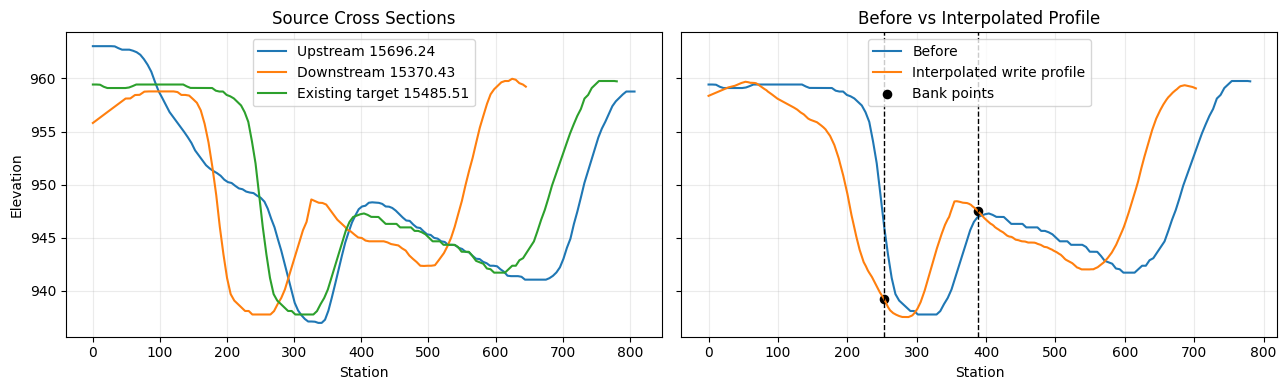

In [5]:
upstream_profile = GeomCrossSection.get_station_elevation(geom_file, river, reach, upstream_rs)
downstream_profile = GeomCrossSection.get_station_elevation(geom_file, river, reach, downstream_rs)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

axes[0].plot(upstream_profile["Station"], upstream_profile["Elevation"], label=f"Upstream {upstream_rs}", linewidth=1.5)
axes[0].plot(downstream_profile["Station"], downstream_profile["Elevation"], label=f"Downstream {downstream_rs}", linewidth=1.5)
axes[0].plot(before_profile["Station"], before_profile["Elevation"], label=f"Existing target {target_rs}", linewidth=1.5)
axes[0].set_title("Source Cross Sections")
axes[0].set_xlabel("Station")
axes[0].set_ylabel("Elevation")
axes[0].legend()
axes[0].grid(True, alpha=0.25)

axes[1].plot(before_profile["Station"], before_profile["Elevation"], label="Before", linewidth=1.5)
axes[1].plot(interpolated["Station"], interpolated["Elevation"], label="Interpolated write profile", linewidth=1.5)
for bank in before_banks:
    axes[1].axvline(bank, color="black", linestyle="--", linewidth=1)
axes[1].scatter(
    interpolated.loc[interpolated["IsBankPoint"], "Station"],
    interpolated.loc[interpolated["IsBankPoint"], "Elevation"],
    color="black",
    s=35,
    label="Bank points",
)
axes[1].set_title("Before vs Interpolated Profile")
axes[1].set_xlabel("Station")
axes[1].legend()
axes[1].grid(True, alpha=0.25)

fig.tight_layout()

In [6]:
profile_backup = GeomCrossSection.set_station_elevation(
    geom_file,
    river,
    reach,
    target_rs,
    interpolated[["Station", "Elevation"]],
    bank_left=before_banks[0],
    bank_right=before_banks[1],
    create_backup=True,
)

bank_backup = GeomCrossSection.set_bank_stations(
    geom_file,
    river,
    reach,
    target_rs,
    before_banks[0],
    before_banks[1],
    create_backup=True,
)

coeff_backup = GeomCrossSection.set_expansion_contraction(
    geom_file,
    river,
    reach,
    target_rs,
    expansion=0.45,
    contraction=0.15,
    create_backup=True,
)

after_profile = GeomCrossSection.get_station_elevation(geom_file, river, reach, target_rs)
after_banks = GeomCrossSection.get_bank_stations(geom_file, river, reach, target_rs)
after_exp_cntr = GeomCrossSection.get_expansion_contraction(geom_file, river, reach, target_rs)

for bank in after_banks:
    assert after_profile["Station"].sub(bank).abs().min() <= 0.005
assert after_banks == before_banks
assert after_exp_cntr == (0.45, 0.15)
assert len(after_profile) <= GeomCrossSection.MAX_XS_POINTS

summary = pd.DataFrame([
    {"Metric": "Profile points", "Before": len(before_profile), "After": len(after_profile)},
    {"Metric": "Bank stations", "Before": before_banks, "After": after_banks},
    {"Metric": "Exp/Cntr", "Before": before_exp_cntr, "After": after_exp_cntr},
    {"Metric": "Profile backup", "Before": "", "After": Path(profile_backup).name},
    {"Metric": "Bank backup", "Before": "", "After": Path(bank_backup).name},
    {"Metric": "Coefficient backup", "Before": "", "After": Path(coeff_backup).name},
])

display(summary)

,Metric,Before,After
0,Profile points,93,222
1,Bank stations,"(253.16, 387.82)","(253.16, 387.82)"
2,Exp/Cntr,"(0.3, 0.1)","(0.45, 0.15)"
3,Profile backup,,Muncie.g01.bak
4,Bank backup,,Muncie.g01.bak1
5,Coefficient backup,,Muncie.g01.bak2


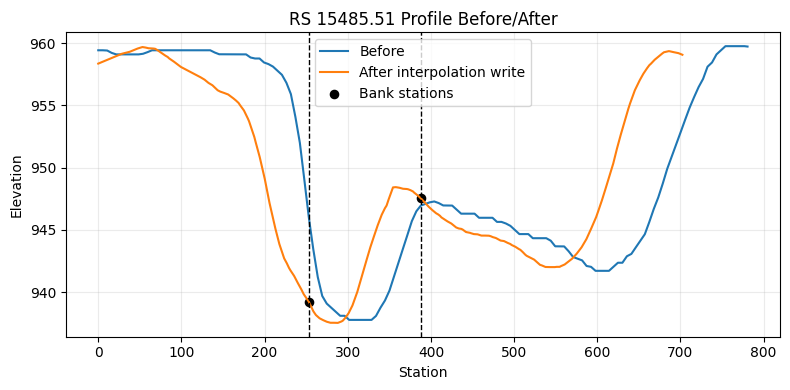

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(before_profile["Station"], before_profile["Elevation"], label="Before", linewidth=1.5)
ax.plot(after_profile["Station"], after_profile["Elevation"], label="After interpolation write", linewidth=1.5)
for bank in after_banks:
    ax.axvline(bank, color="black", linestyle="--", linewidth=1)
ax.scatter(
    after_profile.loc[after_profile["Station"].isin(after_banks), "Station"],
    after_profile.loc[after_profile["Station"].isin(after_banks), "Elevation"],
    color="black",
    s=35,
    label="Bank stations",
)
ax.set_title(f"RS {target_rs} Profile Before/After")
ax.set_xlabel("Station")
ax.set_ylabel("Elevation")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()

In [8]:
compute_folder = work_dir / "Muncie_clb306_xs_settings_compute"
compute_result = RasCmdr.compute_plan(
    plan_number,
    dest_folder=compute_folder,
    overwrite_dest=True,
    clear_geompre=True,
    force_rerun=True,
    num_cores=1,
    verify=True,
)

print(f"HEC-RAS validation success: {compute_result.success}")
assert compute_result.success

init_ras_project(compute_folder, ras_version)
validation_row = ras.results_df.loc[ras.results_df["plan_number"].eq(plan_number)]
display(validation_row[["plan_number", "completed", "has_errors", "has_warnings", "runtime_complete_process_hours", "hdf_exists", "hdf_path"]])

HEC-RAS validation success: True


,plan_number,completed,has_errors,has_warnings,runtime_complete_process_hours,hdf_exists,hdf_path
0,01,True,False,False,0.003533,True,H:\Symphony\ras-commander\CLB-306\xs_interpola...
